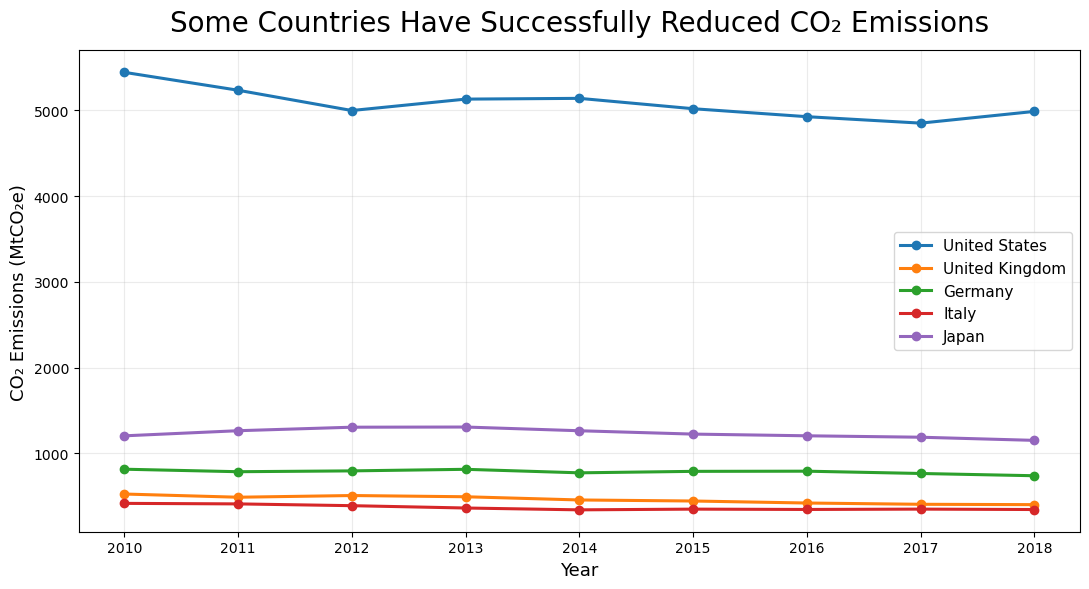

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("./df.csv")

years = [str(y) for y in range(1995, 2022)]

indicator_total = "CO2 emissions embodied in production, Metric ton of CO₂ equivalent"

prod = df[df["INDICATOR"] == indicator_total].copy()
prod = prod[["COUNTRY", "INDICATOR"] + years]

for y in years:
    prod[y] = pd.to_numeric(prod[y], errors="coerce")

valid_years = [y for y in years if prod[y].notna().sum() > 50]



country_totals = prod.groupby("COUNTRY")[valid_years].sum()



recent_years = [y for y in valid_years if int(y) >= 2010]
global_recent = country_totals[recent_years].sum()





country_recent = country_totals[recent_years]

declining = country_recent[
    country_recent[recent_years[-1]] < country_recent[recent_years[0]]
]

top_declining = (
    (declining[recent_years[0]] - declining[recent_years[-1]])
    .sort_values(ascending=False)
    .head(5)
    .index
)

declining_data = country_recent.loc[top_declining]

plt.figure(figsize=(11, 6))
for country in declining_data.index:
    plt.plot(
        [int(y) for y in recent_years],
        declining_data.loc[country],
        marker="o",
        linewidth=2.2,
        label=country
    )

plt.title("Some Countries Have Successfully Reduced CO₂ Emissions", fontsize=20, pad=14)
plt.xlabel("Year", fontsize=13)
plt.ylabel("CO₂ Emissions (MtCO₂e)", fontsize=13)
plt.grid(True, alpha=0.25)
plt.legend(frameon=True, fontsize=11)

plt.tight_layout()
plt.show()



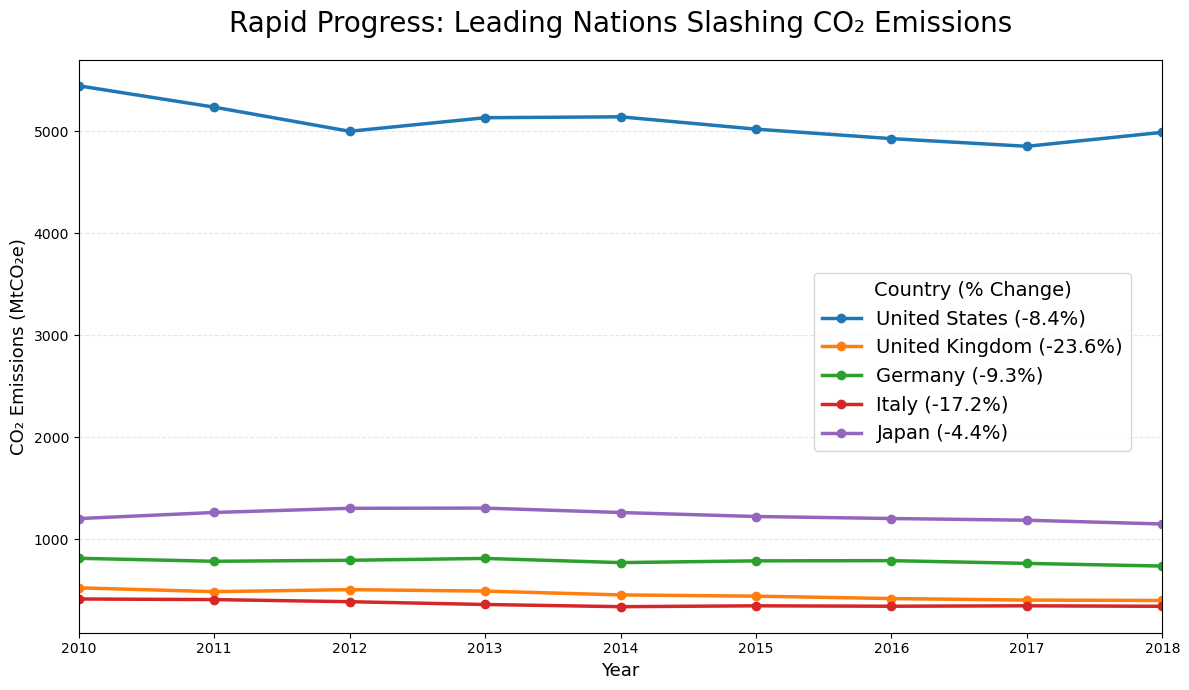

In [32]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("./df.csv")

years = [str(y) for y in range(1995, 2022)]

indicator_total = "CO2 emissions embodied in production, Metric ton of CO₂ equivalent"

prod = df[df["INDICATOR"] == indicator_total].copy()
prod = prod[["COUNTRY", "INDICATOR"] + years]

for y in years:
    prod[y] = pd.to_numeric(prod[y], errors="coerce")

valid_years = [y for y in years if prod[y].notna().sum() > 50]



country_totals = prod.groupby("COUNTRY")[valid_years].sum()



recent_years = [y for y in valid_years if int(y) >= 2010]
global_recent = country_totals[recent_years].sum()





country_recent = country_totals[recent_years]

declining = country_recent[
    country_recent[recent_years[-1]] < country_recent[recent_years[0]]
]

top_declining = (
    (declining[recent_years[0]] - declining[recent_years[-1]])
    .sort_values(ascending=False)
    .head(5)
    .index
)

declining_data = country_recent.loc[top_declining]

plt.figure(figsize=(12, 7))

for country in declining_data.index:
    series = declining_data.loc[country]
    start_val = series[recent_years[0]]
    end_val = series[recent_years[-1]]
    pct_change = ((end_val - start_val) / start_val) * 100
    
    line, = plt.plot(
        [int(y) for y in recent_years],
        series,
        marker="o",
        linewidth=2.5,
        label=f"{country} ({pct_change:.1f}%)"
    )

plt.title("Rapid Progress: Leading Nations Slashing CO₂ Emissions", fontsize=20, pad=20)
plt.xlabel("Year", fontsize=13)
plt.ylabel("CO₂ Emissions (MtCO₂e)", fontsize=13)

# 2. Fix the Legend: Move it to the bottom-right whitespace
# bbox_to_anchor=(1, 0) puts it in the very bottom right corner
plt.legend(
    title="Country (% Change)", 
    frameon=True, 
    fontsize=14, 
    loc='lower right', 
    bbox_to_anchor=(0.98, 0.3),
    title_fontsize=14
)

# 3. Fix the X-axis: Crop it precisely to the data range
plt.xlim(int(recent_years[0]), int(recent_years[-1]))

plt.grid(True, axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()